In [ ]:
import pandas as pd
from keras.optimizers import Adam
from keras.models import Sequential
from keras import activations
from keras.losses import BinaryFocalCrossentropy
from keras.metrics import BinaryAccuracy, Precision, Recall, F1Score
from keras.layers import Activation, Dense, Dropout, BatchNormalization, InputLayer
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [ ]:
SEED = 42
INITIAL_LR = 0.001
FINAL_LR = 0.0001
BATCH_SIZE = 64
MODEL_DIR = 'C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\models'

In [3]:
df = pd.read_csv('C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\data\\processed\\acc_gyr.csv')
df.shape

(96800, 7)

In [4]:
df.head()

,xAcc,yAcc,zAcc,xGyro,yGyro,zGyro,label
0,6.99,-0.57,-7.28,-2.75,-3.23,2.62,1
1,6.51,-0.75,-6.93,-0.67,-6.35,4.64,1
2,6.22,-0.63,-6.73,0.79,-5.49,3.85,1
3,6.34,-0.62,-6.80,1.59,-2.26,0.67,1
4,6.49,-0.39,-6.60,0.67,-0.24,-1.10,1


In [5]:
df['label'].value_counts()

label
0    68800
1    28000
Name: count, dtype: int64

# Treino, Teste e Validação

In [6]:
X = df.drop('label', axis=1)
y = df['label']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=SEED, stratify=y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((67760, 6), (67760,), (14520, 6), (14520,), (14520, 6), (14520,))

# Arquiteura da Rede Neural

In [ ]:
model = Sequential([
    InputLayer(shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    BatchNormalization(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(1, activation='sigmoid'),
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,681 (1.01 MB)

 Trainable params: 262,961 (1.00 MB)

 Non-trainable params: 720 (2.81 KB)

In [10]:
optimizer = Adam(learning_rate=INITIAL_LR)
loss_function = BinaryFocalCrossentropy(alpha=1, gamma=5)
metrics=[BinaryAccuracy(name='accuracy'), Precision(), Recall(), F1Score()]

In [11]:
model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)

# Treinamento do Modelo

In [12]:
callbacks = [
    EarlyStopping(monitor='val_recall', patience=20, restore_best_weights=True, mode='max'),
    ModelCheckpoint(f'{MODEL_DIR}/best_model.keras', monitor='val_recall', save_best_only=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_recall', factor=0.5, patience=4, min_lr=FINAL_LR, verbose=1, mode='max')
]

In [13]:
import numpy as np
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = dict(enumerate(weights))
weights

{0: np.float64(0.7034883720930233), 1: np.float64(1.7285714285714286)}

In [14]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=weights
)

Epoch 1/100
2111/2118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7425 - f1_score: 0.4474 - loss: 0.0185 - precision: 0.5531 - recall: 0.6053
Epoch 1: val_recall improved from None to 0.64381, saving model to C:\Users\meerh\OneDrive\Documentos\Projetos\esp32-fall-detection\models/best_model.keras

Epoch 1: finished saving model to C:\Users\meerh\OneDrive\Documentos\Projetos\esp32-fall-detection\models/best_model.keras
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.7728 - f1_score: 0.4487 - loss: 0.0172 - precision: 0.6053 - recall: 0.6171 - val_accuracy: 0.8262 - val_f1_score: 0.4487 - val_loss: 0.0156 - val_precision: 0.7247 - val_recall: 0.6438 - learning_rate: 0.0010
Epoch 2/100
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - f1_score: 0.4487 - loss: 0.0164 - precision: 0.6609 - recall: 0.6192
Epoch 2: val_recall did not improve from 0.64381
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8036 - f1_score: 0.4487 - loss: 0.0163 - precision: 0.6

In [16]:
import matplotlib.pyplot as plt

def plot_recall(history):
    recall = history.history['recall']
    val_recall = history.history['val_recall']
    
    # Define o eixo X (número de épocas)
    epochs = range(1, len(recall) + 1)

    # Configura o tamanho da figura para melhor visualização
    plt.figure(figsize=(10, 6))

    # Plota as linhas de treinamento e validação
    plt.plot(epochs, recall, 'b-', label='Treinamento (Recall)', linewidth=2)
    plt.plot(epochs, val_recall, 'r--', label='Validação (Val_Recall)', linewidth=2)

    # Personaliza títulos e rótulos
    plt.title('Desempenho do Modelo: Recall por Época', fontsize=16, pad=15)
    plt.xlabel('Épocas', fontsize=14)
    plt.ylabel('Recall', fontsize=14)

    # Adiciona uma grade de fundo para facilitar a leitura dos valores
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Adiciona a legenda no canto inferior direito
    plt.legend(loc='lower right', fontsize=12)

    # Ajusta o layout e exibe o gráfico
    plt.tight_layout()
    plt.show()

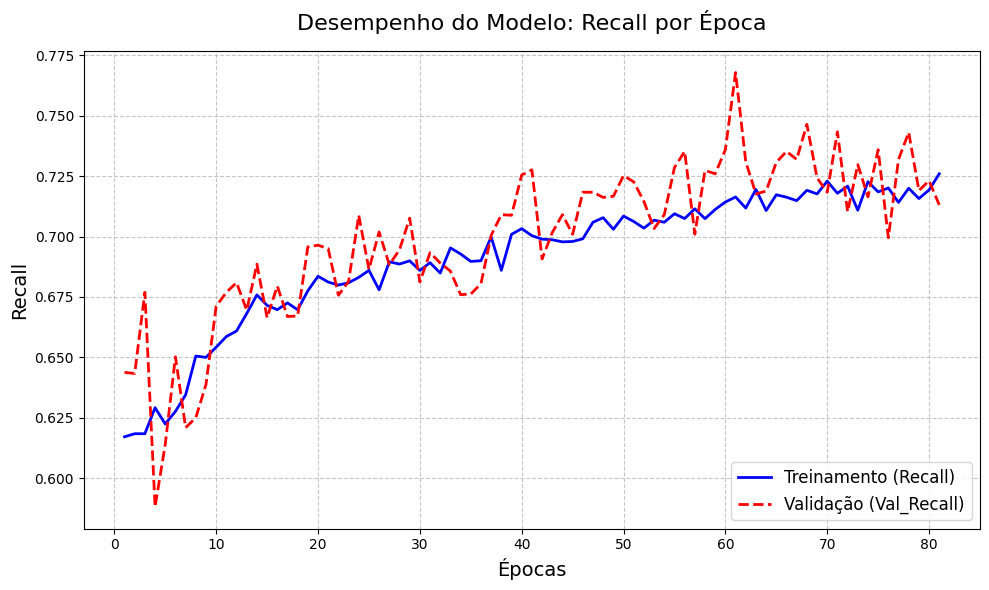

In [17]:
plot_recall(history)